In [33]:
import matplotlib.pyplot as plt
from algorithms.tss_file import TSSFile
import os

In [34]:
def find_file(filename, search_dir):
    for root, dirs, files in os.walk(search_dir):
        if filename in files:
            return root
    return None

In [35]:
folder = r'Y:\TESTDATA\DP\2026\06\18'
tss_file = 'Tek20260618T155848.tss'
path = find_file(tss_file, folder)
tss = TSSFile(path, tss_file, source='Local')
channel_labels = tss.channel_labels
num = len(channel_labels.keys())
print(channel_labels)

{'ch1': 'Vg', 'ch2': 'Vgi', 'ch3': 'Vd', 'ch5': 'Ig', 'ch6': 'Is'}


1


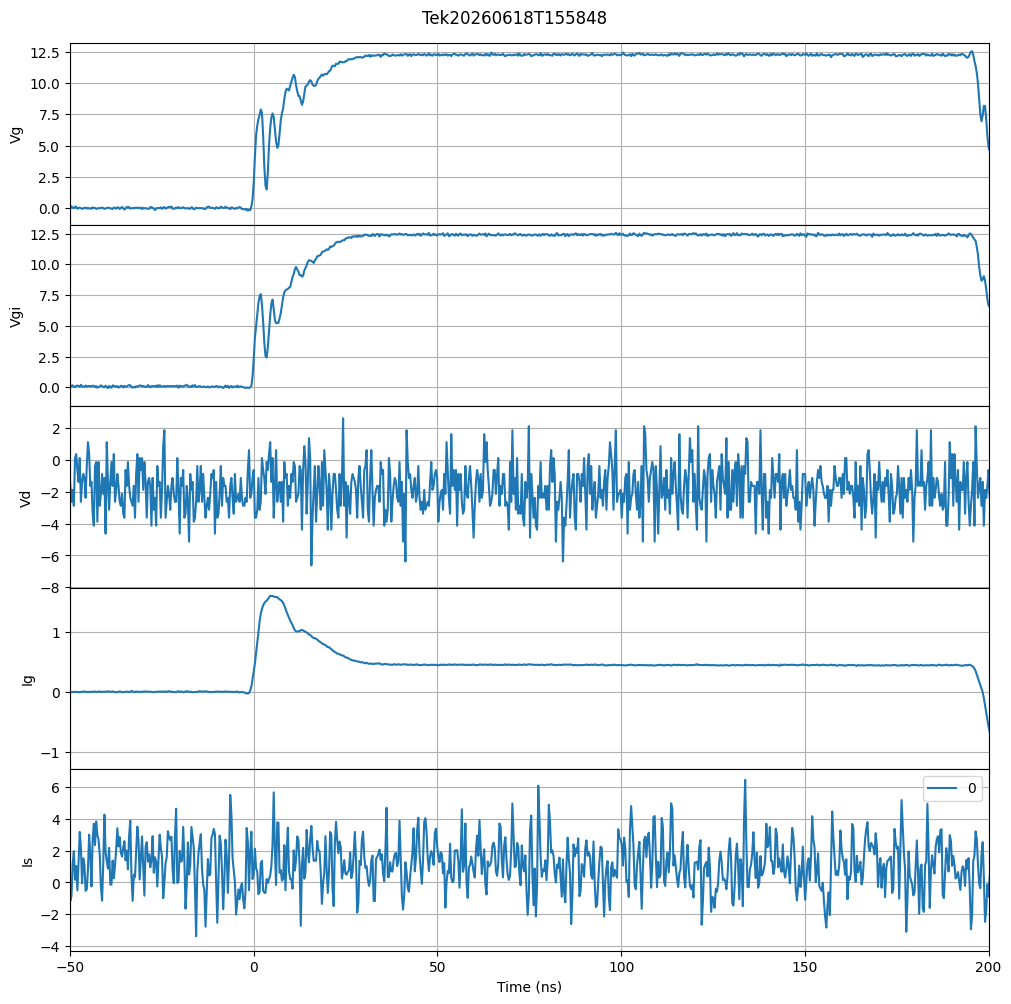

In [36]:
fig, axs = plt.subplots(num, 1, sharex=True, figsize=(10, num*2))
fig.suptitle(tss_file[:-4])
fig.tight_layout()
fig.subplots_adjust(hspace=0)
time1 = tss.waveforms[list(channel_labels.keys())[0]].time_for_frame()*1e9
print(tss.waveforms[list(channel_labels.keys())[0]].frame_count)

for i in [0]:
    index = 0
    for channel in channel_labels.keys():
        values = tss.waveforms[channel].values_for_frame(i)
        axs[index].plot(time1, values, label=i)
        axs[index].set_ylabel(channel_labels[channel])
        axs[index].grid(True)
        index += 1

plt.legend()
plt.xlabel('Time (ns)')
plt.xlim([-50, 200])
#plt.legend(loc='best')
plt.show()